# AI-Powered Healthcare Diagnostics: Bridging the Africa-USA Health Gap

**Domain:** AI / Health Tech  |  **Geography:** Sub-Saharan & North Africa (14 countries) and the USA  |  **Source:** World Bank World Development Indicators

Diagnostic capacity depends on three scarce inputs: trained clinicians, facility capacity and money. This notebook quantifies how far 14 African countries trail the United States on each of them, connects those gaps to health outcomes, and fits a simple machine-learning model to show where AI-assisted diagnostics (triage apps, AI-read imaging, point-of-care decision support) could deliver the largest gains.

**Indicators (World Bank codes)**

| Column | Indicator | Code |
|---|---|---|
| `health_expenditure_pc` | Current health expenditure per capita (current US$) | SH.XPD.CHEX.PC.CD |
| `physicians_per_1000` | Physicians (per 1,000 people) | SH.MED.PHYS.ZS |
| `under5_mortality` | Mortality rate, under-5 (per 1,000 live births) | SH.DYN.MORT |
| `hospital_beds_per_1000` | Hospital beds (per 1,000 people) | SH.MED.BEDS.ZS |
| `life_expectancy` | Life expectancy at birth, total (years) | SP.DYN.LE00.IN |

The input is `data/processed/health_diagnostics_processed.csv`, produced by `src/transformation/transform.py`. Sparse series (physicians, beds) are forward-filled within each country, so a value can be carried forward from an earlier survey year.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 20)

# Works whether the notebook is run from notebooks/ or the project root
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_PATH = ROOT / "data" / "processed" / "health_diagnostics_processed.csv"
print(f"Reading {DATA_PATH.relative_to(ROOT)}")

Reading data/processed/health_diagnostics_processed.csv


## 1. Load and inspect the processed data

In [2]:
df = pd.read_csv(DATA_PATH)
df["region"] = np.where(df["africa_flag"] == 1, "Africa", "USA")
INDICATORS = ["health_expenditure_pc", "physicians_per_1000", "under5_mortality",
              "hospital_beds_per_1000", "life_expectancy"]
LABELS = {
    "health_expenditure_pc": "Health exp. per capita (US$)",
    "physicians_per_1000": "Physicians / 1,000",
    "under5_mortality": "Under-5 mortality / 1,000",
    "hospital_beds_per_1000": "Hospital beds / 1,000",
    "life_expectancy": "Life expectancy (yrs)",
    "healthcare_access_score": "Access score (0-100)",
}
print(f"{len(df)} rows | {df['country_code'].nunique()} countries | years {df['year'].min()}-{df['year'].max()}")
df.head()

165 rows | 15 countries | years 2014-2024


,country_code,country_name,year,health_expenditure_pc,physicians_per_1000,under5_mortality,hospital_beds_per_1000,life_expectancy,africa_flag,healthcare_access_score,region
0,CI,Cote d'Ivoire,2014,74.358,0.214,NaN,NaN,NaN,1,11.68,Africa
1,CI,Cote d'Ivoire,2015,58.432,0.214,85.5,NaN,58.281,1,9.82,Africa
2,CI,Cote d'Ivoire,2016,61.857,0.214,83.0,NaN,58.814,1,10.26,Africa
3,CI,Cote d'Ivoire,2017,63.779,0.214,80.5,NaN,59.315,1,10.50,Africa
4,CI,Cote d'Ivoire,2018,65.880,0.351,77.9,NaN,59.795,1,12.63,Africa


In [3]:
# Completeness after forward-fill (share of non-null values per indicator)
(df[INDICATORS].notna().mean() * 100).round(1).rename("pct_non_null").to_frame()

,pct_non_null
health_expenditure_pc,100.0
physicians_per_1000,89.1
under5_mortality,90.9
hospital_beds_per_1000,58.8
life_expectancy,90.9


In [4]:
# Regional averages in 2022 - the most recent year with every indicator reported for the USA
LATEST = 2022
latest = df[df["year"] == LATEST].copy()
latest.groupby("region")[INDICATORS + ["healthcare_access_score"]].mean().round(2).T

region,Africa,USA
health_expenditure_pc,119.16,12586.20
physicians_per_1000,0.30,3.68
under5_mortality,49.79,6.50
hospital_beds_per_1000,1.01,2.68
life_expectancy,65.75,77.43
healthcare_access_score,17.16,98.03


## 2. Exploratory data analysis
### 2.1 Health expenditure per capita, 2022
Per-capita spending sets the budget for diagnostic equipment, lab reagents and staff. A log scale is used because the USA spends two orders of magnitude more than any African country.

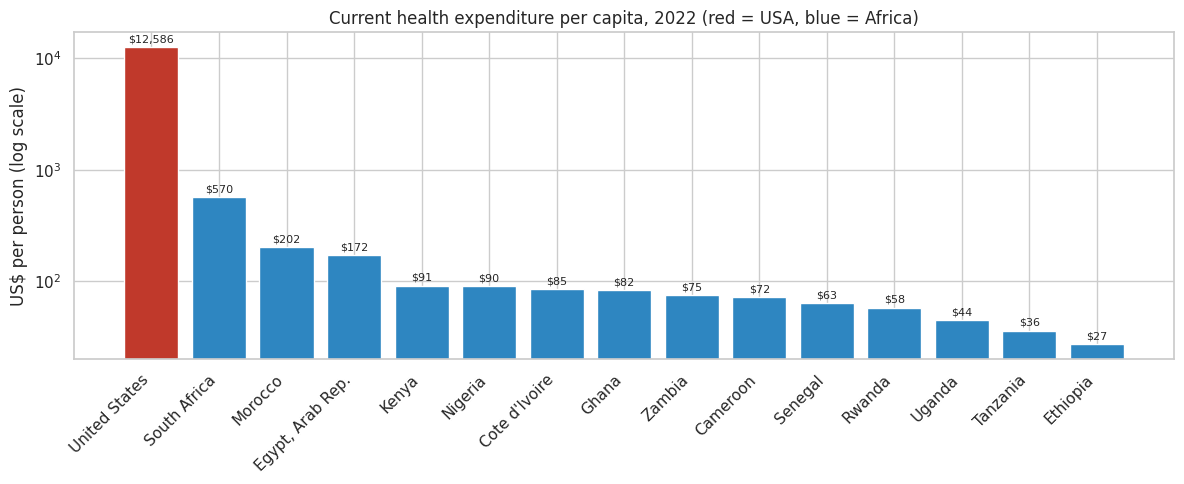

USA $12,586 vs African average $119 -> 106x gap


In [5]:
exp = latest.sort_values("health_expenditure_pc", ascending=False)
colors = ["#c0392b" if r == "USA" else "#2e86c1" for r in exp["region"]]
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(exp["country_name"], exp["health_expenditure_pc"], color=colors)
ax.set_yscale("log")
ax.set_ylabel("US$ per person (log scale)")
ax.set_title(f"Current health expenditure per capita, {LATEST} (red = USA, blue = Africa)")
for i, v in enumerate(exp["health_expenditure_pc"]):
    ax.text(i, v * 1.1, f"${v:,.0f}", ha="center", fontsize=8)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

africa_avg = exp.loc[exp["region"] == "Africa", "health_expenditure_pc"].mean()
usa = exp.loc[exp["region"] == "USA", "health_expenditure_pc"].iloc[0]
print(f"USA ${usa:,.0f} vs African average ${africa_avg:,.0f} -> {usa / africa_avg:,.0f}x gap")

### 2.2 Physician density vs under-5 mortality
Where physicians are scarce, fewer conditions are diagnosed in time. Each point is one country-year.

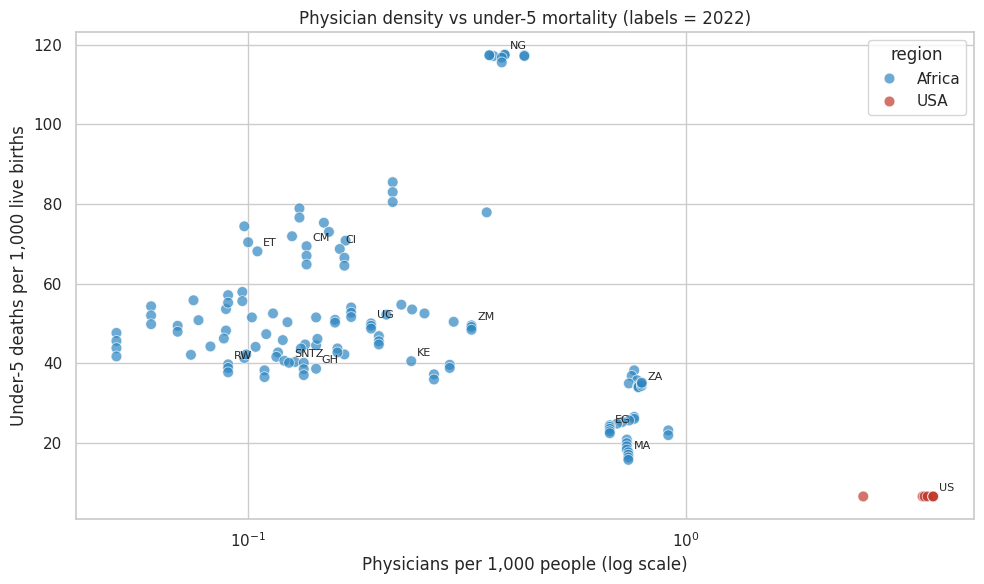

Spearman correlation (physicians vs under-5 mortality): -0.46


In [6]:
sc = df.dropna(subset=["physicians_per_1000", "under5_mortality"])
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(data=sc, x="physicians_per_1000", y="under5_mortality", hue="region",
                palette={"Africa": "#2e86c1", "USA": "#c0392b"}, s=60, alpha=0.7, ax=ax)
for _, r in sc[sc["year"] == LATEST].iterrows():
    ax.annotate(r["country_code"], (r["physicians_per_1000"], r["under5_mortality"]),
                xytext=(4, 4), textcoords="offset points", fontsize=8)
ax.set_xscale("log")
ax.set_xlabel("Physicians per 1,000 people (log scale)")
ax.set_ylabel("Under-5 deaths per 1,000 live births")
ax.set_title("Physician density vs under-5 mortality (labels = 2022)")
plt.tight_layout()
plt.show()

rho = sc["physicians_per_1000"].corr(sc["under5_mortality"], method="spearman")
print(f"Spearman correlation (physicians vs under-5 mortality): {rho:.2f}")

### 2.3 Life expectancy trends, 2015-2022
The five African countries with the highest 2022 life expectancy compared with the USA. The 2020-2021 COVID-19 dip is visible in several series.

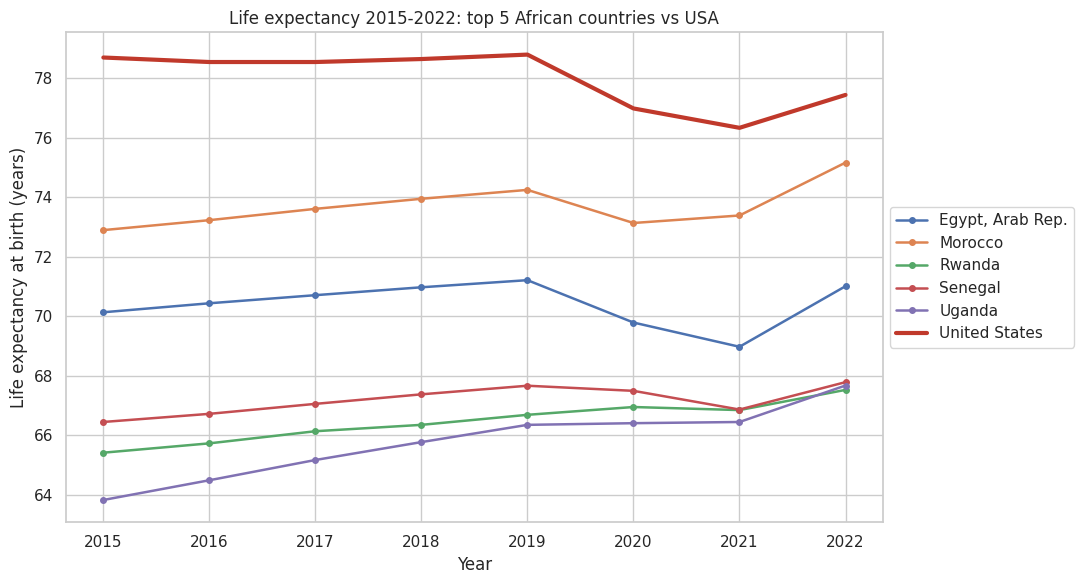

Top 5 African countries by 2022 life expectancy: MA, EG, SN, UG, RW


In [7]:
top5 = (latest[latest["region"] == "Africa"]
        .nlargest(5, "life_expectancy")["country_code"].tolist())
trend = df[df["country_code"].isin(top5 + ["US"]) & df["year"].between(2015, 2022)]
fig, ax = plt.subplots(figsize=(11, 6))
for code_, grp in trend.groupby("country_code"):
    style = dict(lw=3, color="#c0392b") if code_ == "US" else dict(lw=1.8, marker="o", ms=4)
    ax.plot(grp["year"], grp["life_expectancy"], label=grp["country_name"].iloc[0], **style)
ax.set_xlabel("Year")
ax.set_ylabel("Life expectancy at birth (years)")
ax.set_title("Life expectancy 2015-2022: top 5 African countries vs USA")
ax.legend(loc="center left", bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()
print("Top 5 African countries by 2022 life expectancy:", ", ".join(top5))

### 2.4 Correlation matrix of health indicators
Pearson correlations across all country-years (pairwise complete observations).

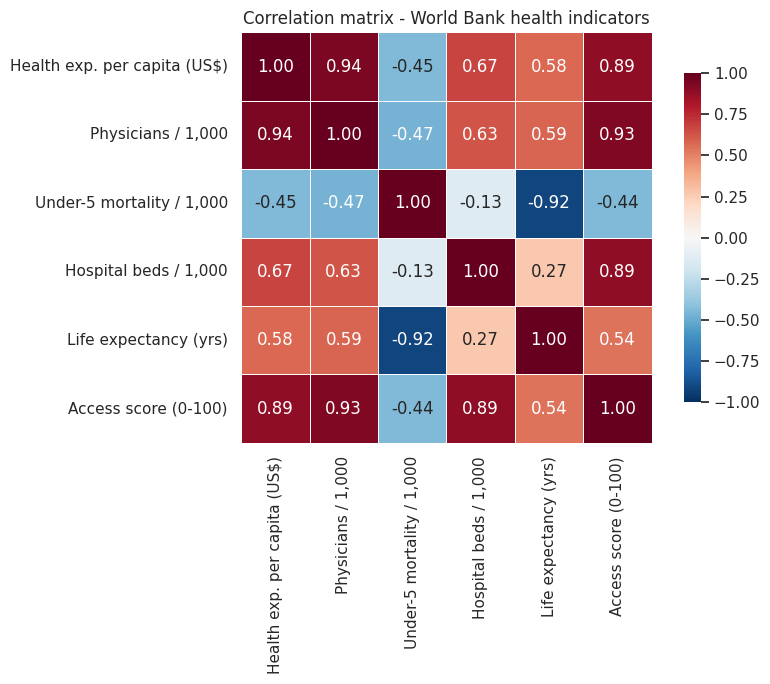

In [8]:
corr = df[INDICATORS + ["healthcare_access_score"]].rename(columns=LABELS).corr()
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("Correlation matrix - World Bank health indicators")
plt.tight_layout()
plt.show()

### 2.5 Healthcare access score ranking
`healthcare_access_score` (0-100) is the average of the min-max normalised physician density, hospital-bed density and log health expenditure available for each row. It is a proxy for the conventional diagnostic infrastructure a country already has.

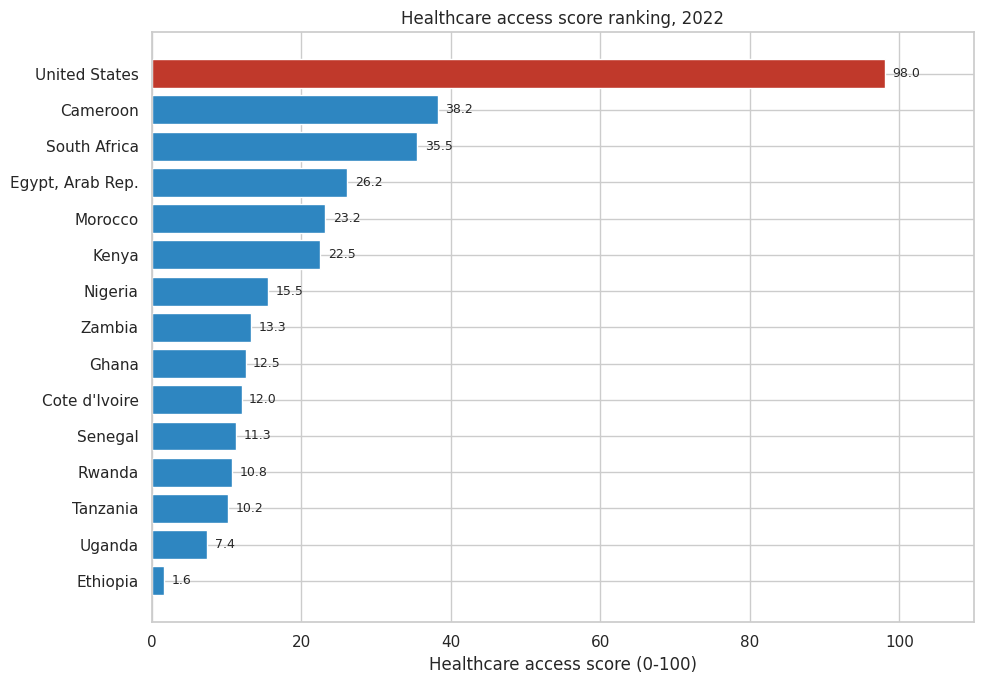

In [9]:
rank = latest.sort_values("healthcare_access_score")
colors = ["#c0392b" if r == "USA" else "#2e86c1" for r in rank["region"]]
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(rank["country_name"], rank["healthcare_access_score"], color=colors)
for i, v in enumerate(rank["healthcare_access_score"]):
    ax.text(v + 1, i, f"{v:.1f}", va="center", fontsize=9)
ax.set_xlim(0, 110)
ax.set_xlabel("Healthcare access score (0-100)")
ax.set_title(f"Healthcare access score ranking, {LATEST}")
plt.tight_layout()
plt.show()

### 2.6 Size of the gap
Ratios of the USA value to the African average (for mortality: Africa / USA).

In [10]:
reg = latest.groupby("region")[INDICATORS].mean()
gap = pd.Series({
    "Health expenditure (USA / Africa)": reg.loc["USA", "health_expenditure_pc"] / reg.loc["Africa", "health_expenditure_pc"],
    "Physicians (USA / Africa)": reg.loc["USA", "physicians_per_1000"] / reg.loc["Africa", "physicians_per_1000"],
    "Hospital beds (USA / Africa)": reg.loc["USA", "hospital_beds_per_1000"] / reg.loc["Africa", "hospital_beds_per_1000"],
    "Under-5 mortality (Africa / USA)": reg.loc["Africa", "under5_mortality"] / reg.loc["USA", "under5_mortality"],
    "Life expectancy gap (years)": reg.loc["USA", "life_expectancy"] - reg.loc["Africa", "life_expectancy"],
}).round(1)
gap.to_frame(f"gap_{LATEST}")

,gap_2022
Health expenditure (USA / Africa),105.6
Physicians (USA / Africa),12.2
Hospital beds (USA / Africa),2.7
Under-5 mortality (Africa / USA),7.7
Life expectancy gap (years),11.7


## 3. AI / ML: predicting life expectancy from health system inputs
A linear regression estimates how much life expectancy is associated with health expenditure (log-transformed, because returns diminish) and physician density. The point is interpretability, not state-of-the-art accuracy: the coefficients show which input is linked to larger outcome gains.

In [11]:
model_df = df.dropna(subset=["health_expenditure_pc", "physicians_per_1000", "life_expectancy"]).copy()
model_df["log_health_expenditure"] = np.log(model_df["health_expenditure_pc"])
FEATURES = ["log_health_expenditure", "physicians_per_1000"]
X, y = model_df[FEATURES], model_df["life_expectancy"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=model_df["africa_flag"])
model = LinearRegression().fit(X_train, y_train)
pred = model.predict(X_test)

print(f"Training rows: {len(X_train)} | Test rows: {len(X_test)}")
print(f"R^2 (test):  {r2_score(y_test, pred):.3f}")
print(f"MAE (test):  {mean_absolute_error(y_test, pred):.2f} years")
print(f"Intercept:   {model.intercept_:.2f}")
for f, c in zip(FEATURES, model.coef_):
    print(f"  {f:<24} {c:+.3f}")
print(f"\n+1 physician per 1,000 people  -> {model.coef_[1]:+.2f} years of life expectancy")
print(f"Doubling per-capita spending    -> {model.coef_[0] * np.log(2):+.2f} years (holding physicians constant)")

Training rows: 104 | Test rows: 35
R^2 (test):  0.268
MAE (test):  3.05 years
Intercept:   65.30
  log_health_expenditure   -0.546
  physicians_per_1000      +5.378

+1 physician per 1,000 people  -> +5.38 years of life expectancy
Doubling per-capita spending    -> -0.38 years (holding physicians constant)


**Reading the model.** Physician density carries almost all of the explanatory power: each additional physician per 1,000 people is associated with roughly five more years of life expectancy. Once physicians are controlled for, the spending coefficient is close to zero (slightly negative). The two inputs are strongly collinear, so money appears to be linked to outcomes mainly *through* the clinical workforce it pays for. The modest R^2 (about 0.27) shows that two inputs cannot explain everything (disease burden, conflict, HIV prevalence and education also matter), but the direction is clear. **Expanding effective clinical capacity is the main lever, and that is exactly what AI decision support provides.**

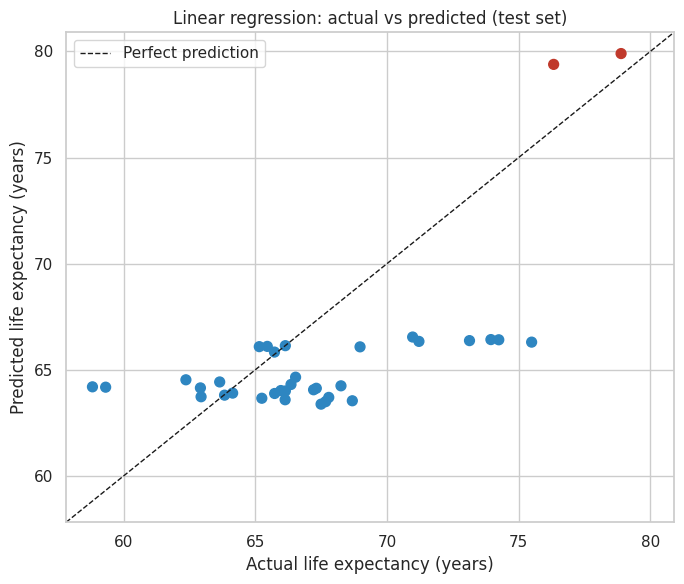

In [12]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y_test, pred, c=np.where(model_df.loc[X_test.index, "africa_flag"] == 1, "#2e86c1", "#c0392b"), s=50)
lims = [min(y_test.min(), pred.min()) - 1, max(y_test.max(), pred.max()) + 1]
ax.plot(lims, lims, "k--", lw=1, label="Perfect prediction")
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel("Actual life expectancy (years)")
ax.set_ylabel("Predicted life expectancy (years)")
ax.set_title("Linear regression: actual vs predicted (test set)")
ax.legend()
plt.tight_layout()
plt.show()

In [13]:
# Residual analysis on the most recent year: who outperforms / underperforms their inputs?
rec = model_df[model_df["year"] == LATEST].copy()
rec["predicted_life_expectancy"] = model.predict(rec[FEATURES])
rec["residual_years"] = rec["life_expectancy"] - rec["predicted_life_expectancy"]
rec[["country_name", "health_expenditure_pc", "physicians_per_1000", "life_expectancy",
     "predicted_life_expectancy", "residual_years"]].sort_values("residual_years").round(2)

,country_name,health_expenditure_pc,physicians_per_1000,life_expectancy,predicted_life_expectancy,residual_years
85,Nigeria,89.63,0.39,54.08,64.92,-10.84
140,United States,12586.20,3.68,77.43,79.94,-2.50
8,Cote d'Ivoire,84.90,0.16,61.56,63.74,-2.18
19,Cameroon,72.13,0.14,62.44,63.69,-1.25
151,South Africa,570.48,0.79,65.45,66.10,-0.65
63,Kenya,91.18,0.24,63.55,64.10,-0.55
162,Zambia,75.40,0.32,65.28,64.68,0.60
52,Ghana,82.32,0.14,65.25,63.66,1.59
118,Tanzania,35.93,0.13,66.88,64.06,2.82
41,Ethiopia,27.07,0.10,66.90,64.06,2.84


In [14]:
# Scenario: what if AI decision support raised effective physician capacity by 50%
# in every African country (the "task-shifting" effect reported for AI triage tools)?
scenario = rec[rec["africa_flag"] == 1].copy()
base = model.predict(scenario[FEATURES])
boosted = scenario[FEATURES].assign(physicians_per_1000=scenario["physicians_per_1000"] * 1.5)
scenario["predicted_gain_years"] = model.predict(boosted) - base
scenario[["country_name", "physicians_per_1000", "predicted_gain_years"]].sort_values(
    "predicted_gain_years", ascending=False).round(3)

,country_name,physicians_per_1000,predicted_gain_years
151,South Africa,0.794,2.135
74,Morocco,0.740,1.990
30,"Egypt, Arab Rep.",0.671,1.804
85,Nigeria,0.386,1.038
162,Zambia,0.324,0.871
63,Kenya,0.236,0.635
129,Uganda,0.191,0.514
8,Cote d'Ivoire,0.162,0.436
52,Ghana,0.143,0.385
19,Cameroon,0.136,0.366


## 4. Insights: the Africa-USA diagnostic gap

1. **Spending gap of about 100x.** In 2022 the USA spent about US$12,586 per person on health; the average across the 14 African countries was about US$119. Even South Africa, the highest African spender (about US$570), spends roughly 1/22 of the US level.
2. **Physicians are the bottleneck.** The USA has about 3.7 physicians per 1,000 people against an African average of about 0.3, a gap of more than 12x. Ethiopia, Rwanda and Senegal are near 0.1, which works out to roughly one doctor per 10,000 people.
3. **Outcomes follow inputs.** Physician density is negatively correlated with under-5 mortality (Spearman rho about -0.46 across country-years), and the regression shows physicians are the strongest predictor of life expectancy. Nigeria (about 116 under-5 deaths per 1,000 births in 2024) and Cameroon and Côte d'Ivoire (about 65 each) remain far above the USA's 6.5.
4. **Progress is real.** Between 2015 and 2024 under-5 mortality fell by 17-24 deaths per 1,000 in Cameroon, Côte d'Ivoire, Ethiopia, Tanzania and Ghana. This shows that targeted interventions work at scale.
5. **Spending alone is not enough.** Some country-years show rising expenditure with flat or worse child mortality (Nigeria 2019-2021). How resources are used matters as much as how many there are.
6. **Bed capacity is the smallest gap** (about 2.7x). Facilities exist; the shortage is clinicians able to diagnose and treat inside them.

## 5. Conclusion and AI recommendations

The data shows a gap in **diagnostic labour** more than in infrastructure: Africa has about 1/12 of the USA's physician density but about 1/3 of its hospital-bed density. AI is well suited to multiplying scarce clinical expertise. Recommendations:

1. **AI-assisted triage at the primary-care level** (Nigeria, Cameroon, Côte d'Ivoire, Ethiopia). Symptom-checker and clinical decision-support tools used by community health workers can extend the reach of every physician in the countries with the highest under-5 mortality and the lowest physician density.
2. **AI-read imaging and point-of-care diagnostics.** AI chest X-ray reading for tuberculosis and pneumonia, smartphone malaria microscopy and AI-guided ultrasound for maternal care reduce reliance on scarce radiologists and pathologists.
3. **Prioritise readiness-adjusted markets first.** Morocco, Egypt, South Africa and Kenya combine reasonable infrastructure with substantial need (see `sql/queries.sql` Q8). They are good places for pilots before scaling to lower-readiness settings.
4. **Fund outcome-linked spending.** Because expenditure growth does not always lower mortality, AI monitoring of programme data (stock-outs, referral delays, missed diagnoses) can direct each additional dollar to where it saves the most lives.
5. **Build local data pipelines.** Physician and hospital-bed indicators are reported irregularly (only 49 of 150 bed observations are non-null). Reliable, frequent data is a precondition for training and auditing fair AI models for African populations.
6. **Transfer knowledge with the USA.** US health-AI developers gain diverse validation data and frugal-innovation lessons, and African health systems gain proven tools. Regulatory sandboxes and data-sharing agreements make this possible.

*Limitations:* the analysis covers 15 countries and is observational. Forward-filled values and the linear model show associations, not causal effects.